In [34]:
import rootutils

# rootutils.setup_root(__file__, indicator=".project-root", pythonpath=True)
# from src.utils.plotting import accumulate_client_metrics, accumulate_master_metrics
import os
import sys

# Manually set the project root directory
project_root = "/home/aladin/latest/resilient_sfl"  # Update this to the actual path
os.chdir(project_root)

# Add the project root to the Python path
if project_root not in sys.path:
    sys.path.append(project_root)

import pandas as pd
import matplotlib.pyplot as plt
import os
import yaml
from omegaconf import OmegaConf, DictConfig
from typing import List, Dict


import os
import pandas as pd

import matplotlib.pyplot as plt
import yaml
from matplotlib.image import imread
from omegaconf import OmegaConf, DictConfig
import tikzplotlib

from typing import List, Dict, Optional

import rootutils
from src.utils.plotting import accumulate_client_metrics, accumulate_master_metrics

from IPython.display import display, clear_output
import time 


def fetch_relevant_directories(main_dir: str, dataset: str, model: str) -> list:
    """
    Traverse the main directory and fetch subdirectories that match the dataset and model criteria.
    
    Parameters:
    - main_dir (str): Path to the main directory.
    - dataset (str): Target dataset.
    - model (str): Target model.

    Returns:
    - list: List of subdirectories that match the criteria.
    """
    matched_dirs = []
    
    # List all subdirectories in the main directory
    subdirs = [d for d in os.listdir(main_dir) if os.path.isdir(os.path.join(main_dir, d))]
    
    for subdir in subdirs:

        tags_path = os.path.join(main_dir, subdir, "tags.log")

        if os.path.exists(tags_path):
            with open(tags_path, 'r') as file:
                content = file.read()

                # Extracting tags from the content
                tags = [tag.strip() for tag in content.strip("[]").split(",")]
                if dataset in tags[0] and model in tags[1]:
                    matched_dirs.append(os.path.join(main_dir, subdir))
    
    return matched_dirs


def fetch_configuration(directory: str) -> DictConfig:
    """
    Fetch and interpret the configuration from `config_tree.yaml` in the given directory.
    
    Parameters:
    - directory (str): Path to the target directory.

    Returns:
    - DictConfig: Configuration dictionary.
    """
    config_path = os.path.join(directory, "config_tree.yaml")
    
    with open(config_path, 'r') as file:
        config = yaml.safe_load(file)
    
    return OmegaConf.create(config)


def generate_multiplot(main_dir: str, dataset: str, model: str, client_name="client_0", plot_name="multiplot.png"):
    """
    Generate a multiplot for all the subfolders that match the given dataset and model.
    """
    # Fetch all relevant directories based on the dataset and model
    directories = fetch_relevant_directories(main_dir, dataset, model)
    
    # Number of directories fetched
    num_dirs = len(directories)
    
    # Calculate the layout for the subplots
    cols = 2
    rows = (num_dirs + 1) // cols
    
    # Create the main figure for multiplot
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    
    for idx, directory in enumerate(directories):
        # Fetch the configuration for the current directory
        config = fetch_configuration(directory)

        # Handle relative paths
        relative_path_components = config.paths.client_log_path.split('/logs/', 1)[-1].split("/")
        relative_path = os.path.join(*relative_path_components[3:4])
        relative_path = os.path.join(relative_path, 'logs/')  
        config.paths.log_path = os.path.join(main_dir, relative_path)

        # Fetch the scenario from the config or tags.log
        scenario = config.tags[-1] if "tags" in config else None
        if not scenario:
            with open(os.path.join(directory, "tags.log"), 'r') as file:
                content = file.read()
                tags = [tag.strip() for tag in content.strip("[]").split(",")]
                scenario = tags[-1]

        # Determine the current subplot axis
        ax = axes[idx // cols, idx % cols] if rows > 1 else axes[idx % cols]

        # Plot the metrics for the current directory on the current subplot axis
        client_train_df, client_val_df = accumulate_client_metrics(config, client_name + "_logger", config.paths.log_path)
        master_train_df, master_val_df = accumulate_master_metrics(config, config.paths.log_path)

        # Extracting parameters from the configuration
        task = config.task_name
        if task == "sc":
            # Plot val metrics for client and master model for sequence classification
            ax.plot(client_val_df['epoch'], client_val_df['val_acc'], label=f'{client_name}', color='blue', linestyle='-', marker='o')
            ax.plot(master_val_df['epoch'], master_val_df['test_acc'], label='Global SFL Model', color='red', linestyle='-', marker='o')
            
            ax.set_ylabel('Accuracy')
        
        elif task == "ner":
            # Plot F1 score metrics for client and master model for NER            
            ax.plot(client_val_df['epoch'], client_val_df['val_f1'], label=f'{client_name}', color='blue', linestyle='-', marker='o')
            ax.plot(master_val_df['epoch'], master_val_df['test_f1'], label='Global SFL Model', color='red', linestyle='-', marker='o')
            
            ax.set_ylabel('F1 Score')
        
        # Set the y-axis scale
        ax.set_ylim(0.4, 1)

        # Set scenario titles
        title_mapping = {
            "None": "Baseline Performance without the Wireless Channel",
            "no_jammer": "No Jamming, only Wireless Impairments",
            "no_protection": "Adversarial Jamming without Protection",
            "w_protection": "Adversarial Jamming with Protection",
        }
        ax.set_title(title_mapping.get(scenario, "Baseline Performance without the Wireless Channel"))
        
        ax.set_xlabel('Cumulative Epochs')
        ax.grid(True, alpha=0.5)
    
    # Remove any unused subplots
    for j in range(idx + 1, rows * cols):
        fig.delaxes(axes.flatten()[j])

    # Add a single legend for the whole figure
    lines, labels = ax.get_legend_handles_labels()
    fig.legend(lines, labels, loc='lower center', fancybox=True, shadow=True, ncol=2)

    # Title
    main_title_fontsize = 20
    subtext_fontsize = 12
    model = config.tags[1].split("_")[0]
    model_task = "Sequence Classification" if task == "sc" else "Named Entity Recognition"
    dataset_name = config.tags[0]
    num_labels = config.model.config.num_labels
    num_clients = config.sfl.num_clients
    num_epochs = config.sfl.num_epochs
    num_rounds = config.sfl.num_rounds

    if task == "sc":
        main_title = 'Classification Accuracies across Global Rounds and Epochs'

    elif task == "ner":
        main_title = 'F1 Scores across Global Rounds and Epochs'

    # fig.suptitle('Classification Accuracies across Global Rounds and Epochs', fontsize=20)
    subtext = f"Model Type: {model}, Model Task: {model_task}, Dataset: {dataset_name}, Number of Labels: {num_labels}, Number of Clients: {num_clients}, Number of Epochs: {num_epochs}, Number of SFL Rounds: {num_rounds}" 
    
    fig.suptitle(main_title, fontsize=main_title_fontsize)
    fig.text(0.5, 0.92, subtext, ha='center', va='center', fontsize=subtext_fontsize)
    # fig.text(0.5, 0.92, 'Your Sub-Title Here', ha='center', va='center', fontsize=16)

    # Tight layout and save the multiplot
    plt.tight_layout()

    # Adjust spacing and layout
    # plt.subplots_adjust(bottom=0.1)
    plt.subplots_adjust(bottom=0.1, top=0.85)

    plt.savefig(os.path.join(main_dir, plot_name))


def generate_joint_bar_plot(main_dir: str, 
                            dataset: str, 
                            model: str, 
                            plot_data: str = "client", 
                            client_name="client_0", 
                            plot_name="barplot.png"):
    """
    Generate a joint bar plot for all subfolders that match the given dataset and model.
    """
    # Fetch all relevant directories based on the dataset and model
    directories = fetch_relevant_directories(main_dir, dataset, model)
    
    # Create the main figure for the bar plot
    fig, ax = plt.subplots(figsize=(15, 7))
    
    # Lists to store bar plot data
    scenarios = []
    client_metrics = []
    master_metrics = []
    
    # Loop through each directory and accumulate data
    for directory in directories:
        # Fetch the configuration for the current directory
        config = fetch_configuration(directory)

        # Handle relative paths
        relative_path_components = config.paths.client_log_path.split('/logs/', 1)[-1].split("/")
        relative_path = os.path.join(*relative_path_components[3:4])
        relative_path = os.path.join(relative_path, 'logs/')  
        config.paths.log_path = os.path.join(main_dir, relative_path)

        # Handle potential errors while fetching scenario
        try:
            scenario = config.tags[-1] if "tags" in config else None
            if not scenario:
                with open(os.path.join(directory, "tags.log"), 'r') as file:
                    content = file.read()
                    tags = [tag.strip() for tag in content.strip("[]").split(",")]
                    scenario = tags[-1]
        except Exception as e:
            print(f"Error fetching scenario for directory {directory}: {e}")
            continue
        
        # Fetch metrics for the current directory
        client_train_df, client_val_df = accumulate_client_metrics(config, client_name + "_logger", config.paths.log_path)
        master_train_df, master_val_df = accumulate_master_metrics(config, config.paths.log_path)
        
        # Extracting task from the configuration
        task = config.get("task_name", "")
        
        # Plot client data based on the task
        label_mapping = {
            "None": "Baseline Performance without the Wireless Channel",
            "no_jammer": "No Jamming, only Wireless Impairments",
            "no_protection": "Adversarial Jamming without Protection",
            "w_protection": "Adversarial Jamming with Protection",
        }

        # label_scenario = label_mapping.get(scenario, scenario)
        label_scenario = label_mapping.get(scenario, scenario).replace(", ", ",\n")

        scenarios.append(label_scenario)
        
        # Accumulate metrics for bar plotting
        if task == "sc":
            client_metrics.append(client_val_df['val_acc'].iloc[-1]) 
            master_metrics.append(master_val_df['test_acc'].iloc[-1])
        elif task == "ner":
            client_metrics.append(client_val_df['val_f1'].iloc[-1])
            master_metrics.append(master_val_df['test_f1'].iloc[-1])

    # Plotting bars
    bar_width = 0.35
    indices = list(range(len(scenarios)))
    
    if plot_data in ["client", "both"]:
        ax.bar(indices, client_metrics, bar_width, label='Client Model', alpha=0.8)
        
    if plot_data in ["master", "both"]:
        # If both client and master data are plotted, shift master bars to the right for clarity
        if plot_data == "both":
            indices = [i + bar_width for i in indices]
        ax.bar(indices, master_metrics, bar_width, label='Global SFL Model', alpha=0.8)
    
    # Formatting
    ax.set_ylim(0.4, 1)
    ax.set_xlabel('Scenarios')
    ax.set_ylabel('Metric Value')
    ax.set_xticks([i + bar_width/2 for i in range(len(scenarios))])
    # ax.set_xticklabels(scenarios, rotation=30, ha='right')
    ax.set_xticklabels(scenarios, ha='center')

    # Set title
    main_title_fontsize = 16
    subtitle_fontsize = 10
    model = config.tags[1].split("_")[0]
    model_task = "Sequence Classification" if task == "sc" else "Named Entity Recognition"
    dataset_name = config.tags[0]
    num_labels = config.model.config.num_labels
    num_clients = config.sfl.num_clients
    num_epochs = config.sfl.num_epochs
    num_rounds = config.sfl.num_rounds

    if task == "sc":
        main_title = 'Classification Accuracies across Global Rounds and Epochs'

    elif task == "ner":
        main_title = 'F1 Scores across Global Rounds and Epochs'

    subtitle = f"Model Type: {model}, Model Task: {model_task}, Dataset: {dataset_name}, Number of Labels: {num_labels}, Number of Clients: {num_clients}, Number of Epochs: {num_epochs}, Number of SFL Rounds: {num_rounds}"
    plt.suptitle(main_title, fontsize=main_title_fontsize)  
    plt.title(subtitle, fontsize=subtitle_fontsize)

    ax.grid(True, alpha=0.5)
    # ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.10), fancybox=True, shadow=True, ncol=4)
    ax.legend(loc='upper right', fancybox=True, shadow=True, ncol=2)
    plt.subplots_adjust(bottom=0.25)

    # Adjust spacing and layout
    plt.tight_layout()

    plt.savefig(os.path.join(main_dir, plot_name))



def generate_joint_plot(main_dir: str, 
                        dataset: str, 
                        model: str, 
                        plot_data: str = "client", 
                        client_name="client_0", 
                        plot_name="jointplot.png",
                        ax=None):
    """
    Generate a joint plot for all subfolders that match the given dataset and model.
    
    Parameters:
    - main_dir: Main directory path.
    - dataset: Dataset name.
    - model: Model name.
    - plot_data: A string which can be "client", "master", or "both" to decide which data to plot.
    - client_name: The name of the client.
    - plot_name: The name of the saved plot.
    
    """
    # Fetch all relevant directories based on the dataset and model
    directories = fetch_relevant_directories(main_dir, dataset, model)

    # Create the main figure for the joint plot
    ax_provided = True
    if ax is None:
        fig, ax = plt.subplots(figsize=(15, 7))
        ax_provided = False

    # Loop through each directory and plot the data
    for directory in directories:
        # Fetch the configuration for the current directory
        config = fetch_configuration(directory)

        # Handle relative paths
        relative_path_components = config.paths.client_log_path.split('/logs/', 1)[-1].split("/")
        relative_path = os.path.join(*relative_path_components[3:4])
        relative_path = os.path.join(relative_path, 'logs/')  
        config.paths.log_path = os.path.join(main_dir, relative_path)

        # Handle potential errors while fetching scenario
        try:
            scenario = config.tags[-1] if "tags" in config else None
            if not scenario:
                with open(os.path.join(directory, "tags.log"), 'r') as file:
                    content = file.read()
                    tags = [tag.strip() for tag in content.strip("[]").split(",")]
                    scenario = tags[-1]
        except Exception as e:
            print(f"Error fetching scenario for directory {directory}: {e}")
            continue
        
        # Fetch metrics for the current directory
        client_train_df, client_val_df = accumulate_client_metrics(config, client_name + "_logger", config.paths.log_path)
        master_train_df, master_val_df = accumulate_master_metrics(config, config.paths.log_path)
        
        # Extracting task from the configuration
        task = config.get("task_name", "")
        
        # Plot client data based on the task
        label_mapping = {
            "None": "Baseline Performance without the Wireless Channel",
            "no_jammer": "No Jamming, only Wireless Impairments",
            "no_protection": "Adversarial Jamming without Protection",
            "w_protection": "Adversarial Jamming with Protection",
        }
        label_scenario = label_mapping.get(scenario, scenario)

        if plot_data in ["client", "both"]:
            if task == "sc":
                ax.plot(client_val_df['epoch'].to_numpy(), client_val_df['val_acc'].to_numpy(), label=f'{label_scenario}', linestyle='-', marker='o')
            elif task == "ner":
                ax.plot(client_val_df['epoch'].to_numpy(), client_val_df['val_f1'].to_numpy(), label=f'{label_scenario}', linestyle='-', marker='o')
        
        # Plot master data based on the task
        if plot_data in ["master", "both"]:
            if task == "sc":
                ax.plot(master_val_df['epoch'].to_numpy(), master_val_df['test_acc'].to_numpy(), label=f'{label_scenario}', linestyle='--', marker='x')
            elif task == "ner":
                ax.plot(master_val_df['epoch'].to_numpy(), master_val_df['test_f1'].to_numpy(), label=f'{label_scenario}', linestyle='--', marker='x')

    # Set the axis parameters
    ax.set_ylim(0.4, 1)
    ax.set_xlabel('Cumulative Epochs')

    # Set title
    main_title_fontsize = 16
    subtitle_fontsize = 10
    model = config.tags[1].split("_")[0]
    model_task = "Sequence Classification" if task == "sc" else "Named Entity Recognition"
    dataset_name = config.tags[0]
    num_labels = config.model.config.num_labels
    num_clients = config.sfl.num_clients
    num_epochs = config.sfl.num_epochs
    num_rounds = config.sfl.num_rounds

    if task == "sc":
        ax.set_ylabel('Accuracy')
        main_title = 'Classification Accuracies across Global Rounds and Epochs'

    elif task == "ner":
        ax.set_ylabel('F1 Score')
        main_title = 'F1 Scores across Global Rounds and Epochs'

    subtitle = f"Model Type: {model}, Model Task: {model_task}, Dataset: {dataset_name}, Number of Labels: {num_labels}, Number of Clients: {num_clients}, Number of Epochs: {num_epochs}, Number of SFL Rounds: {num_rounds}"
    plt.suptitle(main_title, fontsize=main_title_fontsize)  
    plt.title(subtitle, fontsize=subtitle_fontsize) 

    ax.grid(True, alpha=0.5)
    # ax.legend(loc='lower center', fancybox=True, shadow=True, ncol=4)
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.10), fancybox=True, shadow=True, ncol=4)
    plt.subplots_adjust(bottom=0.25)


    # Adjust spacing and layout
    plt.tight_layout()

    # plt.savefig(os.path.join(main_dir, plot_name))
    if not ax_provided:
        plt.savefig(os.path.join(main_dir, plot_name))



def generate_joint_multiplot(main_dir: str,
                             base_model: str,
                             sc_datasets: List[str],
                             ner_datasets: List[str],
                             plot_data: str = "client",
                             client_name: str = "client_0",
                             save_dir: str = "./",
                             plot_name: str = "jointmultiplot.png"):
    """
    Generate a joint multiplot for all subfolders that match the given datasets and model.
    
    Parameters:
    - main_dir: Main directory path.
    - base_model: Base model name (e.g., 'roberta' or 'bert').
    - sc_datasets: List of SC dataset names.
    - ner_datasets: List of NER dataset names.
    - plot_data: A string which can be "client", "master", or "both" to decide which data to plot.
    - client_name: The name of the client.
    - plot_name: The name of the saved plot.
    """
    
    # Model Mapping
    model_mapping: Dict[str, Dict[str, str]] = {
        'roberta': {
            'sc': 'roberta_for_sequence_classification',
            'ner': 'roberta_for_token_classification'
        },
        'bert': {
            'sc': 'bert_for_sequence_classification',
            'ner': 'bert_for_token_classification'
        }
    }
    
    # Label Mapping
    label_mapping: Dict[str, str] = {
        "None": "Baseline Performance without the Wireless Channel",
        "no_jammer": "No Jamming, only Wireless Impairments",
        "no_protection": "Adversarial Jamming without Protection",
        "w_protection": "Adversarial Jamming with Protection"
    }

    # Create a 2x2 subplot
    fig, axs = plt.subplots(2, 2, figsize=(20, 14))
    
    # Get the list of subdirectories in main_dir
    subdirs: List[str] = [os.path.join(main_dir, d) for d in os.listdir(main_dir) if os.path.isdir(os.path.join(main_dir, d))]

    # Initialize an empty set to store unique legend labels
    legend_entries = {}

    # Function to handle plotting for both SC and NER datasets
    def plot_data_for_dataset(row: int, col: int, dataset: str, task: str):
        model = model_mapping[base_model][task]
        metric = 'acc' if task == 'sc' else 'f1'
        ylabel = r'Accuracy' if task == 'sc' else r'F1 Score'
        
        for subdir in subdirs:
            directories = fetch_relevant_directories(subdir, dataset, model)
            if not directories:
                continue

            for directory in directories:
                # Fetch the configuration for the current directory
                config = fetch_configuration(directory)

                # Handle relative paths
                relative_path_components = config.paths.client_log_path.split('/logs/', 1)[-1].split("/")
                relative_path = os.path.join(*relative_path_components[3:4])
                relative_path = os.path.join(relative_path, 'logs/')  
                config.paths.log_path = os.path.join(subdir, relative_path)

                # Get scenario
                try:
                    scenario = config.tags[-1] if "tags" in config else None
                    if not scenario:
                        with open(os.path.join(directory, "tags.log"), 'r') as file:
                            content = file.read()
                            tags = [tag.strip() for tag in content.strip("[]").split(",")]
                            scenario = tags[-1]
                except Exception as e:
                    print(f"Error fetching scenario for directory {directory}: {e}")
                    continue

                # Fetch metrics for the current directory
                client_train_df, client_val_df = accumulate_client_metrics(config, client_name + "_logger", config.paths.log_path)
                master_train_df, master_val_df = accumulate_master_metrics(config, config.paths.log_path)

                # Plot data
                ax = axs[row][col]
                label_scenario = label_mapping.get(scenario, scenario)

                label = f'{label_scenario}'
                if plot_data in ["client", "both"]:
                    line1, = ax.plot(client_val_df['epoch'].to_numpy(), client_val_df[f'val_{metric}'].to_numpy(), label=f'{label_scenario}', linestyle='-', marker='o')
                    legend_entries[label] = line1
                
                if plot_data in ["master", "both"]:
                    line2, = ax.plot(master_val_df['epoch'].to_numpy(), master_val_df[f'test_{metric}'].to_numpy(), label=f'{label_scenario}', linestyle='--', marker='x')
                    legend_entries[label] = line2

                # Set the axis parameters for the subplot
                ax.set_ylim(0., 1) if task == 'sc' or dataset == "conll2003" else ax.set_ylim(0.05, 0.5)
                ax.set_xlabel(r'Cumulative Epochs', fontsize=14)
                ax.set_ylabel(ylabel, fontsize=14)
                ax.set_title(f'{dataset.upper()}',  fontsize=16)
                ax.grid(True, alpha=0.5)

    # Process SC datasets
    for idx, dataset in enumerate(sc_datasets):
        plot_data_for_dataset(0, idx, dataset, 'sc')

    # Process NER datasets
    for idx, dataset in enumerate(ner_datasets):
        plot_data_for_dataset(1, idx, dataset, 'ner')

    fig.legend(handles=legend_entries.values(), 
               labels=legend_entries.keys(), 
               loc='lower center', 
               ncol=len(legend_entries), 
               fancybox=True, 
               shadow=True,
               fontsize=14)
    
    fig.suptitle(r'Performance Metrics for SC and NER NLP Tasks', fontsize=18, fontweight='bold')


    # Set global title, layout, and save figure
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.2, wspace=0.1, bottom=0.09)  
    plt.savefig(os.path.join(save_dir, plot_name))




def generate_jointplot_tikz(main_dir: str, 
                            dataset: str, 
                            model: str, 
                            client_name="client_0", 
                            plot_name="jointplot.png", 
                            lims: list = [0.4, 1]):
    """
    Generate a joint plot for all subfolders that match the given dataset and model, using LaTeX font.
    """
    # Font size configuration
    common_font_size = 16
    axis_ticks_font_size = 16

    # Define known scenarios and their display names
    scenario_display_names = {
        "None": "SFL Baseline",
        "no_jammer": "Gaussian",
        "no_protection": "No Protection",
        "w_protection": "Protection"
    }

    # scenario_display_names = {
    #     "None": "No Wireless Channel",
    #     "no_jammer": "No Attack, only Wireless Impairments",
    #     "no_protection": "Adversarial Attack without Protection",
    #     "w_protection": "Adversarial Attack with Protection"
    # }

    # Fetch all relevant directories based on the dataset and model
    directories = fetch_relevant_directories(main_dir, dataset, model)

    # Create the main figure for joint plot
    fig, ax = plt.subplots(figsize=(15, 10))

    # colors = ['blue', 'red', 'green', 'purple', 'orange', 'brown']
    colors = ['blue', 'red', 'orange', 'green', 'purple', 'brown']
    client_mapping = {
        "client_0": "Client 1",
        "client_1": "Client 2",
        "client_2": "Client 3",
    }

    scenario_colors = {
        "None": "orange",
        "no_jammer": "green",
        "no_protection": "red",
        "w_protection": "blue"
    }

    # Assume configuration is the same for all directories
    if directories:
        config = fetch_configuration(directories[0])

    model_name = config.tags[1].split("_")[0]
    model_task = "Sequence Classification" if config.task_name == "sc" else "Named Entity Recognition"
    dataset_name = config.tags[0]
    num_labels = config.model.config.num_labels
    num_clients = config.sfl.num_clients
    num_epochs = config.sfl.num_epochs
    num_rounds = config.sfl.num_rounds

    for idx, directory in enumerate(directories):
        config = fetch_configuration(directory)

        # Handle relative paths
        relative_path_components = config.paths.client_log_path.split('/logs/', 1)[-1].split("/")
        relative_path = os.path.join(*relative_path_components[3:4])
        relative_path = os.path.join(relative_path, 'logs/')  
        config.paths.log_path = os.path.join(main_dir, relative_path)

        scenario = None
        if "tags" in config:
            for tag in config.tags:
                if tag in scenario_display_names:
                    scenario = tag
                    break

        if not scenario:
            with open(os.path.join(directory, "tags.log"), 'r') as file:
                content = file.read()
                tags = [tag.strip() for tag in content.strip("[]").split(",")]
                for tag in tags:
                    if tag in scenario_display_names:
                        scenario = tag
                        break

        client_train_df, client_val_df = accumulate_client_metrics(config, client_name + "_logger", config.paths.log_path)
        master_train_df, master_val_df = accumulate_master_metrics(config, config.paths.log_path)

        display_name = client_mapping.get(client_name, client_name)

        # color = colors[idx % len(colors)]
        color = scenario_colors.get(scenario, 'black')  # Use 'black' as default if scenario is not found


        if config.task_name == "sc":
            ax.plot(client_val_df['epoch'].to_numpy(), client_val_df['val_acc'].to_numpy(), label=f'{display_name} - {scenario_display_names[scenario]}', color=color, linestyle='-', marker='o')
            ax.set_ylabel('Accuracy', fontsize=common_font_size)
        elif config.task_name == "ner":
            ax.plot(client_val_df['epoch'].to_numpy(), client_val_df['val_f1'].to_numpy(), label=f'{display_name} - {scenario_display_names[scenario]}', color=color, linestyle='-', marker='o')
            ax.set_ylabel('F1 Score', fontsize=common_font_size)

        ax.set_ylim(lims)


        ax.tick_params(axis='both', labelsize=axis_ticks_font_size)

        main_title = 'Classification Accuracies across Global Rounds and Epochs' if config.task_name == "sc" else 'F1 Scores across Global Rounds and Epochs'
        main_title = 'SST2 ROBERTA'

        main_title = f'{dataset_name.upper()} {model_name.upper()}'
        
        subtitle = f"Model Type: {model_name}, Model Task: {model_task}, Dataset: {dataset_name}, Number of Labels: {num_labels}, Number of Clients: {num_clients}, Number of Epochs: {num_epochs}, Number of SFL Rounds: {num_rounds}"

        main_title_fontsize = 24
        subtitle_fontsize = 14
        # plt.suptitle(main_title,fontsize=main_title_fontsize)
        # plt.title(subtitle, fontsize=subtitle_fontsize)
        plt.title(main_title, fontsize=main_title_fontsize, pad=20)

        ax.set_xlabel('Cumulative Epochs', fontsize=common_font_size)
        ax.grid(True, alpha=1)

        # Position the legend outside the plot
        # ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), fancybox=True, shadow=True, ncol=4, fontsize=common_font_size)

        # Tight layout and save the joint plot
        plt.tight_layout()
        plt.subplots_adjust(bottom=0.25, top=0.85)

        tikz_save_path = os.path.join(main_dir, "jointplot.tex")
        tikzplotlib.save(tikz_save_path)
        print(tikz_save_path)

        save_fig(fig, os.path.join(main_dir, plot_name), latex=True, pdf=True)


def generate_jointplot_tikz_interactive(main_dir: str, 
                            dataset: str, 
                            model: str, 
                            client_name="client_0", 
                            plot_name="jointplot.png", 
                            lims: list = [0.4, 1],
                            speed: float = 0.5):
    """
    Generate a joint plot for all subfolders that match the given dataset and model, using LaTeX font.
    """
    # Font size configuration
    common_font_size = 16
    axis_ticks_font_size = 16

    # Define known scenarios and their display names
    scenario_display_names = {
        "None": "SFL Baseline",
        "no_jammer": "Gaussian",
        "no_protection": "No Protection",
        "w_protection": "Protection"
    }

    # Define scenario-to-color mapping
    scenario_colors = {
        "None": "orange",
        "no_jammer": "green",
        "no_protection": "red",
        "w_protection": "blue"
    }

    # Fetch all relevant directories based on the dataset and model
    directories = fetch_relevant_directories(main_dir, dataset, model)

    # Create the main figure for joint plot
    fig, ax = plt.subplots(figsize=(15, 10))

    client_mapping = {
        "client_0": "Client 1",
        "client_1": "Client 2",
        "client_2": "Client 3",
    }

    # Assume configuration is the same for all directories
    if directories:
        config = fetch_configuration(directories[0])

    model_name = config.tags[1].split("_")[0]
    model_task = "Sequence Classification" if config.task_name == "sc" else "Named Entity Recognition"
    dataset_name = config.tags[0]
    num_labels = config.model.config.num_labels
    num_clients = config.sfl.num_clients
    num_epochs = config.sfl.num_epochs
    num_rounds = config.sfl.num_rounds

    plt.ion()  # Turn on interactive mode

    for idx, directory in enumerate(directories):
        config = fetch_configuration(directory)

        # Handle relative paths
        relative_path_components = config.paths.client_log_path.split('/logs/', 1)[-1].split("/")
        relative_path = os.path.join(*relative_path_components[3:4])
        relative_path = os.path.join(relative_path, 'logs/')  
        config.paths.log_path = os.path.join(main_dir, relative_path)

        scenario = None
        if "tags" in config:
            for tag in config.tags:
                if tag in scenario_display_names:
                    scenario = tag
                    break

        if not scenario:
            with open(os.path.join(directory, "tags.log"), 'r') as file:
                content = file.read()
                tags = [tag.strip() for tag in content.strip("[]").split(",")]
                for tag in tags:
                    if tag in scenario_display_names:
                        scenario = tag
                        break

        client_train_df, client_val_df = accumulate_client_metrics(config, client_name + "_logger", config.paths.log_path)
        master_train_df, master_val_df = accumulate_master_metrics(config, config.paths.log_path)

        display_name = client_mapping.get(client_name, client_name)
        color = scenario_colors.get(scenario, 'black')  # Use 'black' as default if scenario is not found

        epochs = client_val_df['epoch'].to_numpy()
        if config.task_name == "sc":
            vals = client_val_df['val_acc'].to_numpy()
            ylabel = 'Accuracy'
        elif config.task_name == "ner":
            vals = client_val_df['val_f1'].to_numpy()
            ylabel = 'F1 Score'

        for i in range(len(epochs)):
            ax.plot(epochs[:i+1], vals[:i+1], label=f'{display_name} - {scenario_display_names[scenario]}', color=color, linestyle='-', marker='o')
            ax.set_ylabel(ylabel, fontsize=common_font_size)
            ax.set_ylim(lims)
            ax.set_xlabel('Cumulative Epochs', fontsize=common_font_size)
            ax.grid(True, alpha=1)
            ax.tick_params(axis='both', labelsize=axis_ticks_font_size)

            main_title = f'{dataset_name.upper()} {model_name.upper()}'
            plt.title(main_title, fontsize=24, pad=20)

            # ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), fancybox=True, shadow=True, ncol=4, fontsize=common_font_size)
            plt.tight_layout()
            plt.subplots_adjust(bottom=0.25, top=0.85)

            display(fig)
            clear_output(wait=True)
            time.sleep(speed)

    plt.ioff()  # Turn off interactive mode

    tikz_save_path = os.path.join(main_dir, "jointplot.tex")
    tikzplotlib.save(tikz_save_path)
    print(tikz_save_path)

    save_fig(fig, os.path.join(main_dir, plot_name), latex=True, pdf=True)


def save_fig(f, save_path: str | os.PathLike, latex: bool = False, pdf: bool = False, **kwargs):
    """
    Saves the figure to the specified path with the given format options.
    """
    stem = os.path.split(save_path)[0]
    if not os.path.isdir(stem):
        os.mkdir(stem)
    f.savefig(
        os.path.join(save_path + ".png"),
        dpi=150,
        bbox_inches="tight",
        **kwargs,
    )
    if pdf:
        f.savefig(
            os.path.join(save_path + ".pdf"),
            dpi=150,
            bbox_inches="tight",
            **kwargs,
        )
    if latex:
        tikzplotlib.save(
            os.path.join(save_path + ".tex"),
            figure=f,
            strict=False,
            **kwargs,
        )


def generate_jointplot_tikz_interactive2(main_dir: str, 
                            dataset: str, 
                            model: str, 
                            client_name="client_0", 
                            plot_name="jointplot.png", 
                            lims: list = [0.4, 1],
                            speed: float = 0.5):
    """
    Generate a joint plot for all subfolders that match the given dataset and model, using LaTeX font.
    """
    # Font size configuration
    common_font_size = 16
    axis_ticks_font_size = 16

    # Define known scenarios and their display names
    scenario_display_names = {
        "None": "SFL Baseline",
        "no_jammer": "Gaussian",
        "no_protection": "No Protection",
        "w_protection": "Protection"
    }

    # Define scenario-to-color mapping
    scenario_colors = {
        "None": "orange",
        "no_jammer": "green",
        "no_protection": "red",
        "w_protection": "blue"
    }

    # Fetch all relevant directories based on the dataset and model
    directories = fetch_relevant_directories(main_dir, dataset, model)

    # Create the main figure for joint plot
    fig, ax = plt.subplots(figsize=(15, 10))

    client_mapping = {
        "client_0": "Client 1",
        "client_1": "Client 2",
        "client_2": "Client 3",
    }

    # Assume configuration is the same for all directories
    if directories:
        config = fetch_configuration(directories[0])

    model_name = config.tags[1].split("_")[0]
    model_task = "Sequence Classification" if config.task_name == "sc" else "Named Entity Recognition"
    dataset_name = config.tags[0]
    num_labels = config.model.config.num_labels
    num_clients = config.sfl.num_clients
    num_epochs = config.sfl.num_epochs
    num_rounds = config.sfl.num_rounds

    plt.ion()  # Turn on interactive mode

    # Initialize a dictionary to store the plot lines for each scenario
    plot_lines = {}
    epochs_data = {}

    for idx, directory in enumerate(directories):
        config = fetch_configuration(directory)

        # Handle relative paths
        relative_path_components = config.paths.client_log_path.split('/logs/', 1)[-1].split("/")
        relative_path = os.path.join(*relative_path_components[3:4])
        relative_path = os.path.join(relative_path, 'logs/')  
        config.paths.log_path = os.path.join(main_dir, relative_path)

        scenario = None
        if "tags" in config:
            for tag in config.tags:
                if tag in scenario_display_names:
                    scenario = tag
                    break

        if not scenario:
            with open(os.path.join(directory, "tags.log"), 'r') as file:
                content = file.read()
                tags = [tag.strip() for tag in content.strip("[]").split(",")]
                for tag in tags:
                    if tag in scenario_display_names:
                        scenario = tag
                        break

        client_train_df, client_val_df = accumulate_client_metrics(config, client_name + "_logger", config.paths.log_path)
        master_train_df, master_val_df = accumulate_master_metrics(config, config.paths.log_path)

        display_name = client_mapping.get(client_name, client_name)
        color = scenario_colors.get(scenario, 'black')  # Use 'black' as default if scenario is not found

        epochs = client_val_df['epoch'].to_numpy()
        if config.task_name == "sc":
            vals = client_val_df['val_acc'].to_numpy()
            ylabel = 'Accuracy'
        elif config.task_name == "ner":
            vals = client_val_df['val_f1'].to_numpy()
            ylabel = 'F1 Score'

        # Initialize the plot lines if not already done
        if scenario not in plot_lines:
            plot_lines[scenario], = ax.plot([], [], label=f'{display_name} - {scenario_display_names[scenario]}', color=color, linestyle='-', marker='o')
            epochs_data[scenario] = (epochs, vals)

    # Find the maximum range for the x-axis
    max_epochs = max([len(epochs) for epochs, vals in epochs_data.values()])

    for i in range(max_epochs):
        for scenario, line in plot_lines.items():
            epochs, vals = epochs_data[scenario]
            line.set_data(epochs[:i+1], vals[:i+1] if i < len(vals) else vals)

        ax.set_xlim(0, max(epochs))
        ax.set_ylabel(ylabel, fontsize=common_font_size)
        ax.set_ylim(lims)
        ax.set_xlabel('Cumulative Epochs', fontsize=common_font_size)
        ax.grid(True, alpha=1)
        ax.tick_params(axis='both', labelsize=axis_ticks_font_size)

        main_title = f'{dataset_name.upper()} {model_name.upper()}'
        plt.title(main_title, fontsize=24, pad=20)

        # ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), fancybox=True, shadow=True, ncol=4, fontsize=common_font_size)
        plt.tight_layout()
        plt.subplots_adjust(bottom=0.25, top=0.85)

        display(fig)
        clear_output(wait=True)
        time.sleep(speed)

    plt.ioff()  # Turn off interactive mode

    tikz_save_path = os.path.join(main_dir, "jointplot.tex")
    tikzplotlib.save(tikz_save_path)
    print(tikz_save_path)

    save_fig(fig, os.path.join(main_dir, plot_name), latex=True, pdf=True)




def generate_jointplot_tikz_interactive3(main_dir: str, 
                            dataset: str, 
                            model: str, 
                            client_name="client_0", 
                            plot_name="jointplot.png", 
                            lims: list = [0.4, 1],
                            speed: float = 0.5):
    """
    Generate a joint plot for all subfolders that match the given dataset and model, using LaTeX font.
    """
    # Font size configuration
    common_font_size = 16
    axis_ticks_font_size = 16

    # Define known scenarios and their display names
    scenario_display_names = {
        "None": "SFL Baseline",
        "no_jammer": "Gaussian",
        "no_protection": "No Protection",
        "w_protection": "Protection"
    }

    # Define scenario-to-color mapping
    scenario_colors = {
        "None": "orange",
        "no_jammer": "green",
        "no_protection": "red",
        "w_protection": "blue"
    }

    # Fetch all relevant directories based on the dataset and model
    directories = fetch_relevant_directories(main_dir, dataset, model)

    # Create the main figure for joint plot
    fig, ax = plt.subplots(figsize=(15, 10))

    client_mapping = {
        "client_0": "Client 1",
        "client_1": "Client 2",
        "client_2": "Client 3",
    }

    # Assume configuration is the same for all directories
    if directories:
        config = fetch_configuration(directories[0])

    model_name = config.tags[1].split("_")[0]
    model_task = "Sequence Classification" if config.task_name == "sc" else "Named Entity Recognition"
    dataset_name = config.tags[0]
    num_labels = config.model.config.num_labels
    num_clients = config.sfl.num_clients
    num_epochs = config.sfl.num_epochs
    num_rounds = config.sfl.num_rounds

    plt.ion()  # Turn on interactive mode

    # Initialize a dictionary to store the plot lines for each scenario
    plot_lines = {}
    epochs_data = {}

    for idx, directory in enumerate(directories):
        config = fetch_configuration(directory)

        # Handle relative paths
        relative_path_components = config.paths.client_log_path.split('/logs/', 1)[-1].split("/")
        relative_path = os.path.join(*relative_path_components[3:4])
        relative_path = os.path.join(relative_path, 'logs/')  
        config.paths.log_path = os.path.join(main_dir, relative_path)

        scenario = None
        if "tags" in config:
            for tag in config.tags:
                if tag in scenario_display_names:
                    scenario = tag
                    break

        if not scenario:
            with open(os.path.join(directory, "tags.log"), 'r') as file:
                content = file.read()
                tags = [tag.strip() for tag in content.strip("[]").split(",")]
                for tag in tags:
                    if tag in scenario_display_names:
                        scenario = tag
                        break

        client_train_df, client_val_df = accumulate_client_metrics(config, client_name + "_logger", config.paths.log_path)
        master_train_df, master_val_df = accumulate_master_metrics(config, config.paths.log_path)

        display_name = client_mapping.get(client_name, client_name)
        color = scenario_colors.get(scenario, 'black')  # Use 'black' as default if scenario is not found

        epochs = client_val_df['epoch'].to_numpy()
        if config.task_name == "sc":
            vals = client_val_df['val_acc'].to_numpy()
            ylabel = 'Accuracy'
        elif config.task_name == "ner":
            vals = client_val_df['val_f1'].to_numpy()
            ylabel = 'F1 Score'

        # Initialize the plot lines if not already done
        if scenario not in plot_lines:
            plot_lines[scenario], = ax.plot([], [], label=f'{display_name} - {scenario_display_names[scenario]}', color=color, linestyle='-', marker='o')
            epochs_data[scenario] = (epochs, vals)

    # Gradually update the plot
    for i in range(len(epochs)):
        for scenario, line in plot_lines.items():
            epochs, vals = epochs_data[scenario]
            line.set_data(epochs[:i+1], vals[:i+1])

        # Update x-axis limit dynamically
        ax.set_xlim(0, epochs[:i+1][-1])

        ax.set_ylabel(ylabel, fontsize=common_font_size)
        ax.set_ylim(lims)
        ax.set_xlabel('Cumulative Epochs', fontsize=common_font_size)
        ax.grid(True, alpha=1)
        ax.tick_params(axis='both', labelsize=axis_ticks_font_size)

        main_title = f'{dataset_name.upper()} {model_name.upper()}'
        plt.title(main_title, fontsize=24, pad=20)

        # ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), fancybox=True, shadow=True, ncol=4, fontsize=common_font_size)
        plt.tight_layout()
        plt.subplots_adjust(bottom=0.25, top=0.85)

        display(fig)
        clear_output(wait=True)
        time.sleep(speed)

    plt.ioff()  # Turn off interactive mode

    # tikz_save_path = os.path.join(main_dir, "jointplot.tex")
    # tikzplotlib.save(tikz_save_path)
    # print(tikz_save_path)

    # save_fig(fig, os.path.join(main_dir, plot_name), latex=True, pdf=True)



# if __name__ == "__main__":

    # generate_joint_multiplot(main_dir='/home/shared/previous/old/plotting',
    #                         base_model='bert',
    #                         sc_datasets=['sst2', 'mrpc'],
    #                         ner_datasets=['wnut_17', 'conll2003'],
    #                         plot_data='client',
    #                         client_name="client_0",
    #                         plot_name="joint_multiplot_bert_new.png")
    
    # generate_multiplot(main_dir='/home/aladin/refactoring/resilient_sfl/logs/sc/multiruns/2023-10-02_22-55-42', 
    #                    dataset='sst2', 
    #                    model='roberta_for_sequence_classification',
    #                    client_name="client_0",
    #                    plot_name="multiplot_sst2_roberta.png")
    




    # generate_joint_plot(main_dir='/home/shared/previous/old/plotting/2023-10-02_22-55-42', 
    #                    dataset='sst2', 
    #                    plot_data='client',
    #                    model='roberta_for_sequence_classification',
    #                    client_name="client_0",
    #                    plot_name="jointplot_sst2_roberta_new.png")
    




    # # SST2 BERT 
    # generate_jointplot_tikz(main_dir='/home/shared/previous/old/plotting/2023-10-02_22-55-42', 
    #                    dataset='sst2', 
    #                    model='bert_for_sequence_classification',
    #                    client_name="client_0",
    #                    plot_name="jointplot_sst2_bert_new.png")


    # # SST2 ROBERTA 
    # generate_jointplot_tikz(main_dir='/home/shared/previous/old/plotting/2023-10-02_22-55-42', 
    #                    dataset='sst2', 
    #                    model='roberta_for_sequence_classification',
    #                    client_name="client_0",
    #                    plot_name="jointplot_sst2_roberta_new.png")
    

    # # CONLL BERT
    # generate_jointplot_tikz(main_dir='/home/shared/previous/old/plotting/icc_logs_ner_vlad', 
    #                    dataset='conll', 
    #                    model='bert_for_token_classification',
    #                    client_name="client_0",
    #                    plot_name="jointplot_conll_bert_new.png",
    #                    lims = [0, 1])
    
    # # CONLL ROBERTA
    # generate_jointplot_tikz(main_dir='/home/shared/previous/old/plotting/icc_logs_ner_vlad', 
    #                    dataset='conll', 
    #                    model='roberta_for_token_classification',
    #                    client_name="client_0",
    #                    plot_name="jointplot_conll_roberta_new.png",
    #                    lims = [0, 1])# 

/home/shared/previous/old/plotting/2023-10-02_22-55-42/jointplot.tex


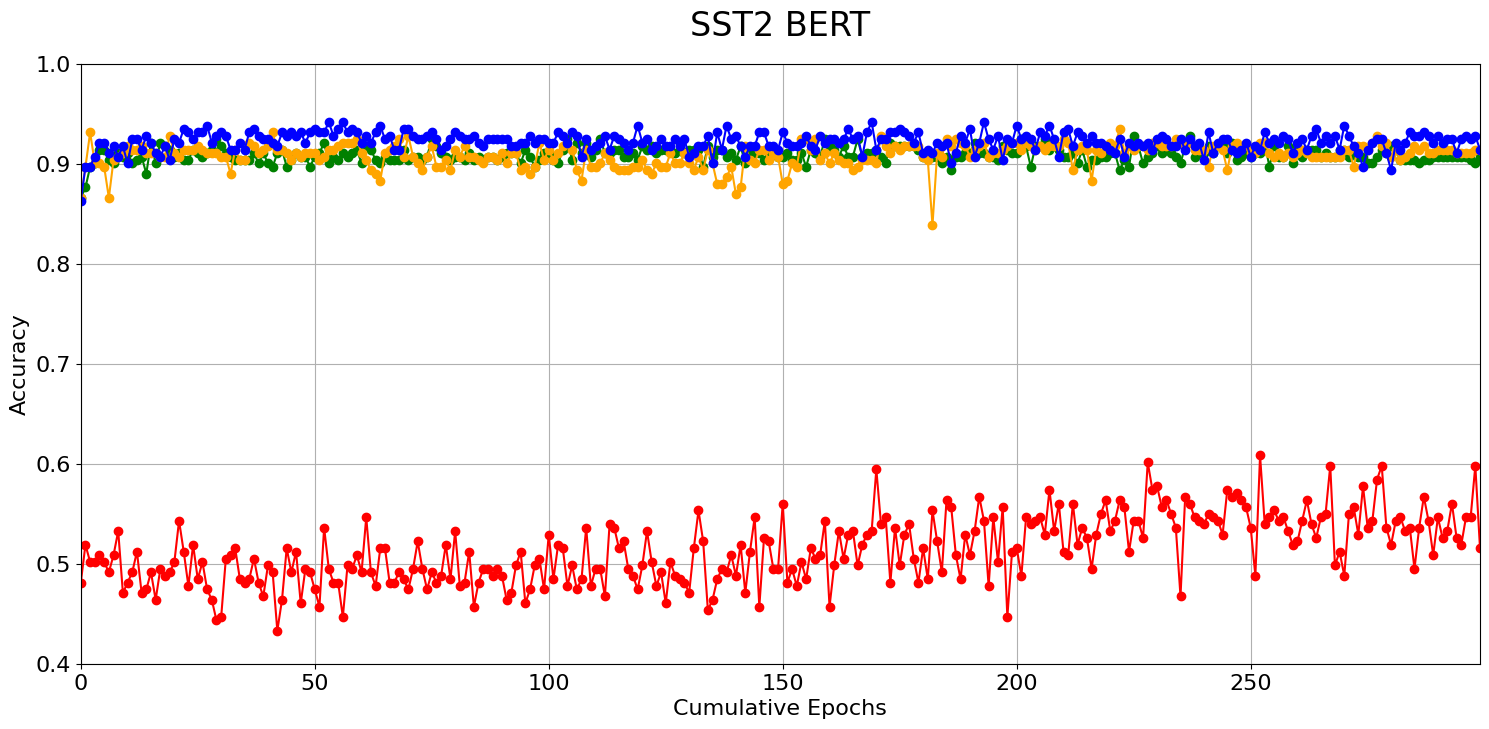

In [32]:
# SST2 BERT 
generate_jointplot_tikz_interactive3(main_dir='/home/shared/previous/old/plotting/2023-10-02_22-55-42', 
                    dataset='sst2', 
                    model='bert_for_sequence_classification',
                    client_name="client_0",
                    plot_name="jointplot_sst2_bert_new.png",
                    speed = 0.001)

In [33]:
# SST2 ROBERTA 
generate_jointplot_tikz_interactive3(main_dir='/home/shared/previous/old/plotting/2023-10-02_22-55-42', 
                   dataset='sst2', 
                   model='roberta_for_sequence_classification',
                   client_name="client_0",
                   plot_name="jointplot_sst2_roberta_new.png",
                   speed=0.001)

/home/shared/previous/old/plotting/2023-10-02_22-55-42/jointplot.tex


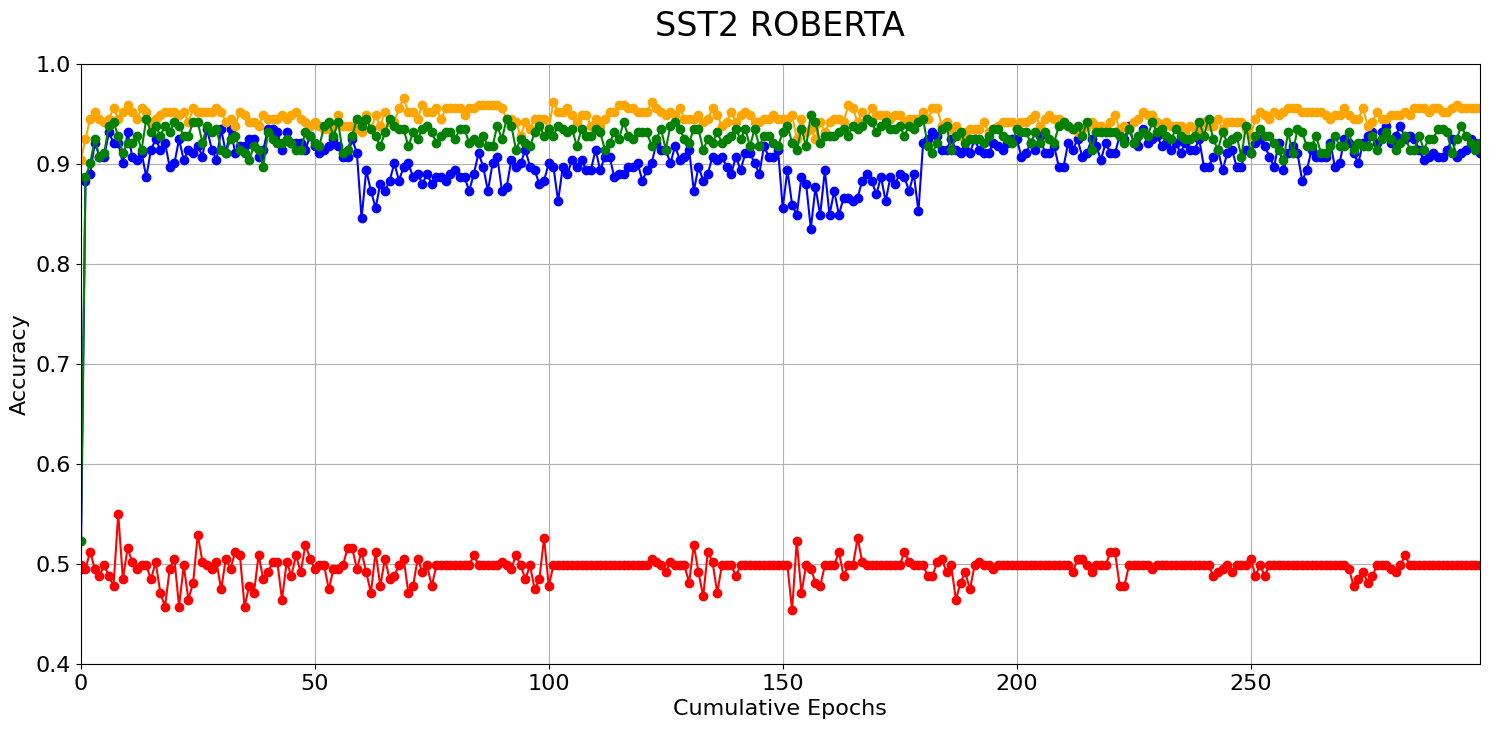

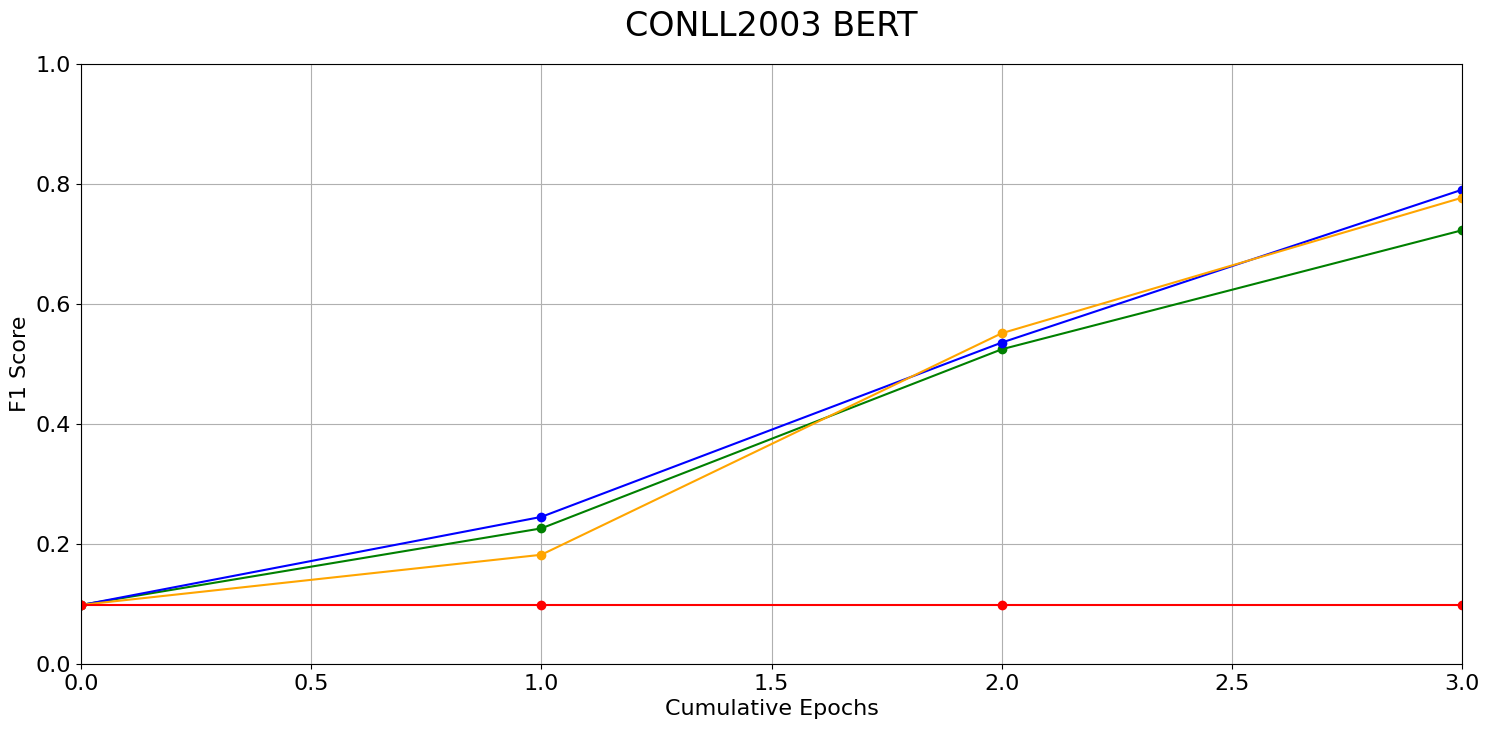

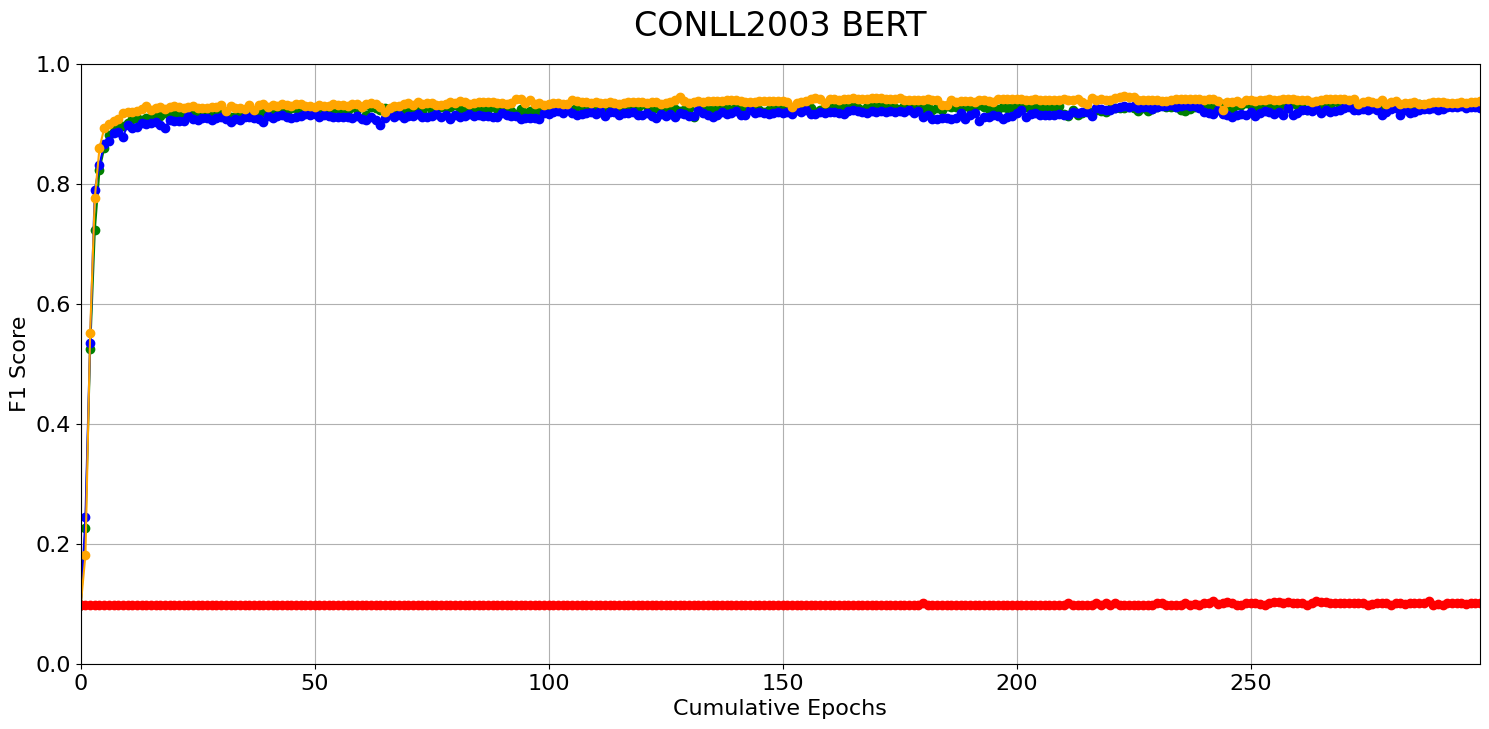

In [36]:
# CONLL BERT
generate_jointplot_tikz_interactive3(main_dir='/home/shared/previous/old/plotting/icc_logs_ner_vlad', 
                   dataset='conll', 
                   model='bert_for_token_classification',
                   client_name="client_0",
                   plot_name="jointplot_conll_bert_new.png",
                   lims = [0, 1],
                   speed=0.001)

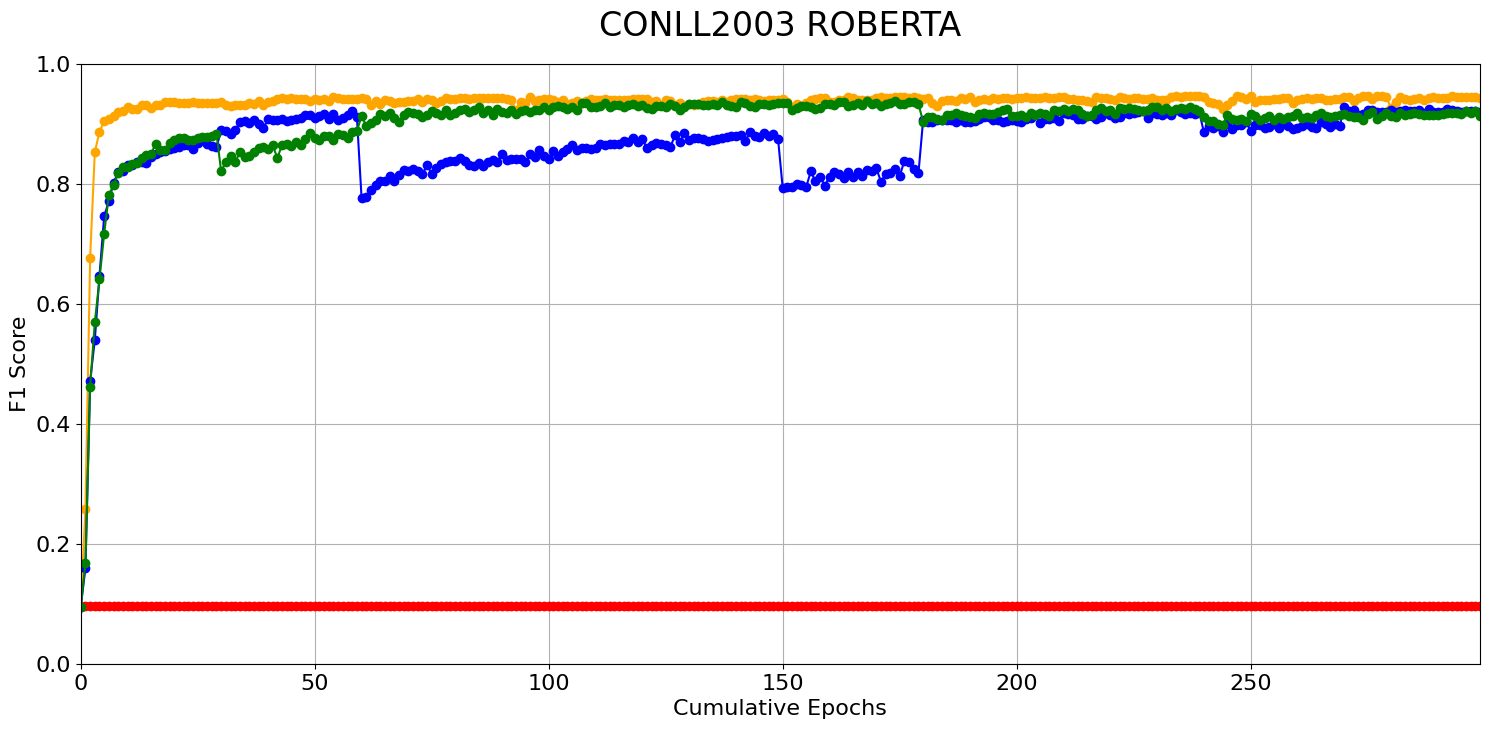

In [37]:
# CONLL ROBERTA
generate_jointplot_tikz_interactive3(main_dir='/home/shared/previous/old/plotting/icc_logs_ner_vlad', 
                   dataset='conll', 
                   model='roberta_for_token_classification',
                   client_name="client_0",
                   plot_name="jointplot_conll_roberta_new.png",
                   lims = [0, 1],
                   speed=0.001)

In [86]:
# GET MSEs

import numpy as np

# Load
mse_filepath = '/home/aladin/latest/resilient_sfl/mse_files/'
all_mses_no_jammer = np.load(mse_filepath + 'mse_no_jammer.npy', allow_pickle=True)
all_mses_no_protection = np.load(mse_filepath + 'mse_no_protection.npy', allow_pickle=True)
all_mses_w_protection = np.load(mse_filepath + 'mse_w_protection.npy', allow_pickle=True)

# User collection
user1 = [[a, b, c] for a, b, c in zip(all_mses_no_jammer[:300, 0], all_mses_no_protection[:300, 0], all_mses_w_protection[:300, 0])]
user2 = [[a, b, c] for a, b, c in zip(all_mses_no_jammer[:300, 1], all_mses_no_protection[:300, 1], all_mses_w_protection[:300, 1])]
user3 = [[a, b, c] for a, b, c in zip(all_mses_no_jammer[:300, 2], all_mses_no_protection[:300, 2], all_mses_w_protection[:300, 2])]

user1 = np.asarray(user1, dtype=np.float32)
user2 = np.asarray(user2, dtype=np.float32)
user3 = np.asarray(user3, dtype=np.float32)

In [89]:
def mse_bar_plot(user_data, user_id):
    """
    Plots a bar plot for the given user's MSE data.
    
    Parameters:
    - user_data: A numpy array of arrays containing three values per entry.
    - user_id: An identifier for the user (e.g., "User 1").
    """
    # Number of entries
    num_entries = user_data.shape[0]
    
    # Calculate mean MSE values for each case
    mean_no_jammer = np.mean(user_data[:, 0])
    mean_jammer = np.mean(user_data[:, 1])
    mean_protection = np.mean(user_data[:, 2])
    
    # Calculate standard deviation for error bars
    std_no_jammer = np.std(user_data[:, 0])
    std_jammer = np.std(user_data[:, 1])
    std_protection = np.std(user_data[:, 2])
    
    # Bar plot
    labels = ['No Jammer', 'Jammer', 'Protection']
    means = [mean_no_jammer, mean_jammer, mean_protection]
    stds = [std_no_jammer, std_jammer, std_protection]
    
    x = np.arange(len(labels))
    
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(x, means, yerr=stds, capsize=5, color=['orange', 'green', 'blue'], alpha=0.7)
    
    ax.set_xlabel('Scenario', fontsize=14)
    ax.set_ylabel('Mean MSE', fontsize=14)
    ax.set_title(f'Mean MSE for {user_id}', fontsize=16)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.grid(True, alpha=0.3)
    
    plt.show()




def mse_bar_plot_log_scale(user_data, user_id):
    """
    Plots a bar plot for the given user's MSE data using a logarithmic scale.
    
    Parameters:
    - user_data: A numpy array of arrays containing three values per entry.
    - user_id: An identifier for the user (e.g., "User 1").
    """
    # Number of entries
    num_entries = user_data.shape[0]
    
    # Calculate mean MSE values for each case
    mean_no_jammer = np.mean(user_data[:, 0])
    mean_jammer = np.mean(user_data[:, 1])
    mean_protection = np.mean(user_data[:, 2])
    
    # Calculate standard deviation for error bars
    std_no_jammer = np.std(user_data[:, 0])
    std_jammer = np.std(user_data[:, 1])
    std_protection = np.std(user_data[:, 2])
    
    # Bar plot
    labels = ['No Jammer', 'Jammer', 'Protection']
    means = [mean_no_jammer, mean_jammer, mean_protection]
    stds = [std_no_jammer, std_jammer, std_protection]
    
    x = np.arange(len(labels))
    
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.bar(x, means, yerr=stds, capsize=5, color=['orange', 'green', 'blue'], alpha=0.7)
    
    ax.set_xlabel('Scenario', fontsize=14)
    ax.set_ylabel('Mean MSE', fontsize=14)
    ax.set_title(f'Mean MSE for {user_id}', fontsize=16)
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_yscale('log')
    ax.grid(True, alpha=0.3)
    
    plt.show()

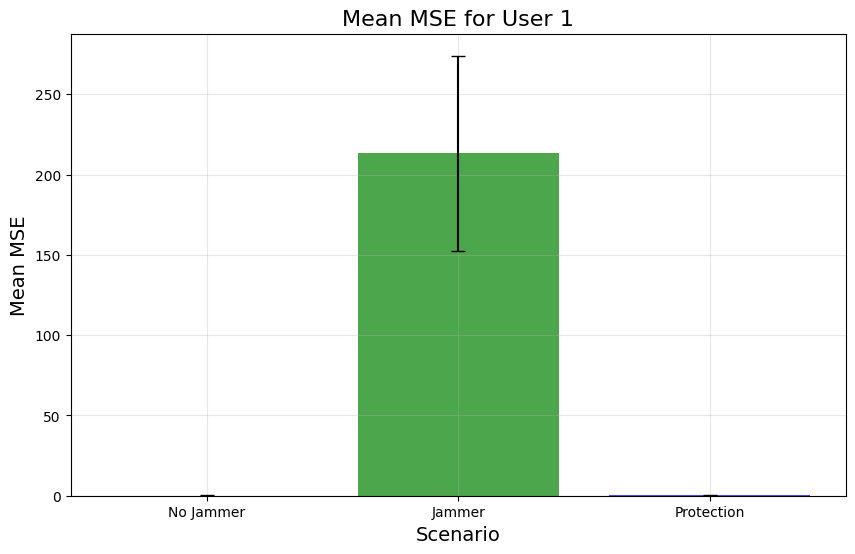

In [88]:
mse_bar_plot(user1, "User 1")

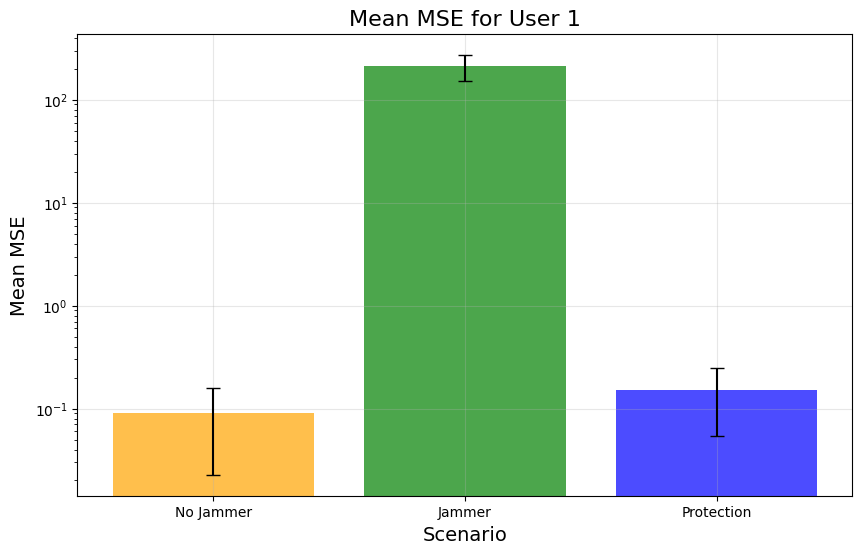

In [90]:
mse_bar_plot_log_scale(user1, "User 1")

In [104]:
def plot_user_scenarios_interactive(user_data, user_id, speed=0.5):
    """
    Plots each of the three scenarios for the given user data in an interactive manner.
    
    Parameters:
    - user_data: A numpy array of arrays containing three values per entry.
    - user_id: An identifier for the user (e.g., "User 1").
    - speed: The delay between each frame in seconds.
    """
    # Font size configuration
    common_font_size = 16
    axis_ticks_font_size = 16

    # Define scenario names and colors
    scenario_names = ['No Jammer', 'Jammer', 'Protection']
    scenario_colors = ['orange', 'green', 'blue']

    # Initialize a dictionary to store the plot lines for each scenario
    plot_lines = {}
    epochs_data = {}

    fig, ax = plt.subplots(figsize=(15, 10))
    
    plt.ion()  # Turn on interactive mode

    for i, scenario in enumerate(scenario_names):
        # Extract the data for the current scenario
        vals = user_data[:, i]
        epochs = np.arange(len(vals))
        
        # Initialize the plot lines if not already done
        plot_lines[scenario], = ax.plot([], [], label=f'{user_id} - {scenario}', color=scenario_colors[i], linestyle='-', marker='o')
        epochs_data[scenario] = (epochs, vals)

    # Gradually update the plot
    max_len = max([len(vals) for _, vals in epochs_data.values()])
    for i in range(max_len):
        for scenario, line in plot_lines.items():
            epochs, vals = epochs_data[scenario]
            line.set_data(epochs[:i+1], vals[:i+1])

        # Update x-axis limit dynamically
        ax.set_xlim(0, epochs[:i+1][-1])

        ax.set_ylabel('MSE', fontsize=common_font_size)
        ax.set_yscale('log')
        ax.set_ylim(min([min(vals) for _, vals in epochs_data.values()]), max([max(vals) for _, vals in epochs_data.values()]))
        ax.set_xlabel('Epochs', fontsize=common_font_size)
        ax.grid(True, alpha=1)
        ax.tick_params(axis='both', labelsize=axis_ticks_font_size)

        main_title = f'MSE for {user_id}'
        plt.title(main_title, fontsize=24, pad=20)

        ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), fancybox=True, shadow=True, ncol=3, fontsize=common_font_size)
        # ax.set_yscale('log')
        plt.tight_layout()
        plt.subplots_adjust(bottom=0.25, top=0.85)

        display(fig)
        clear_output(wait=True)
        time.sleep(speed)

    plt.ioff()  # Turn off interactive mode

KeyboardInterrupt: 

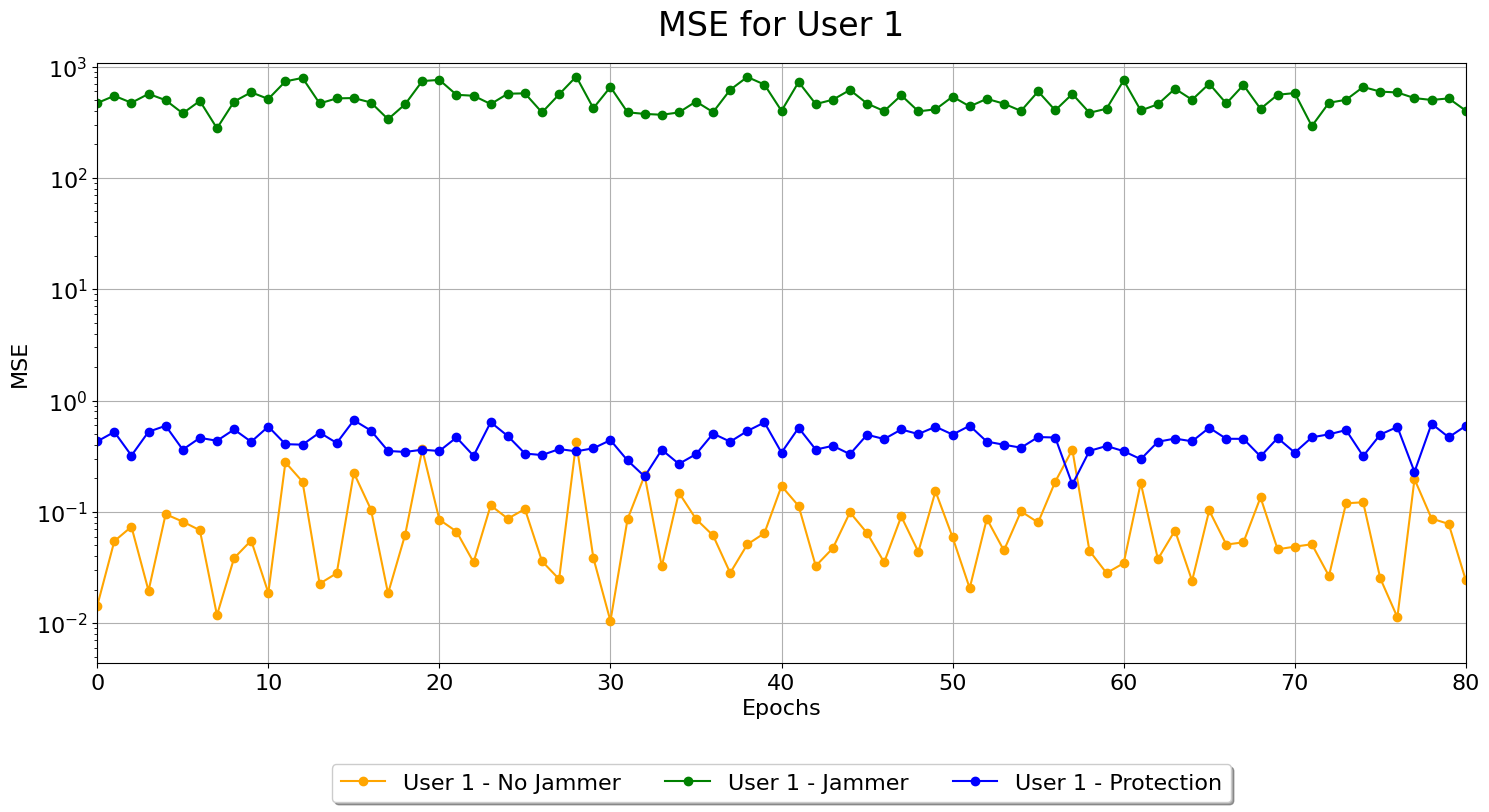

In [106]:
plot_user_scenarios_interactive(user3, "User 1", speed=0.001)

KeyboardInterrupt: 

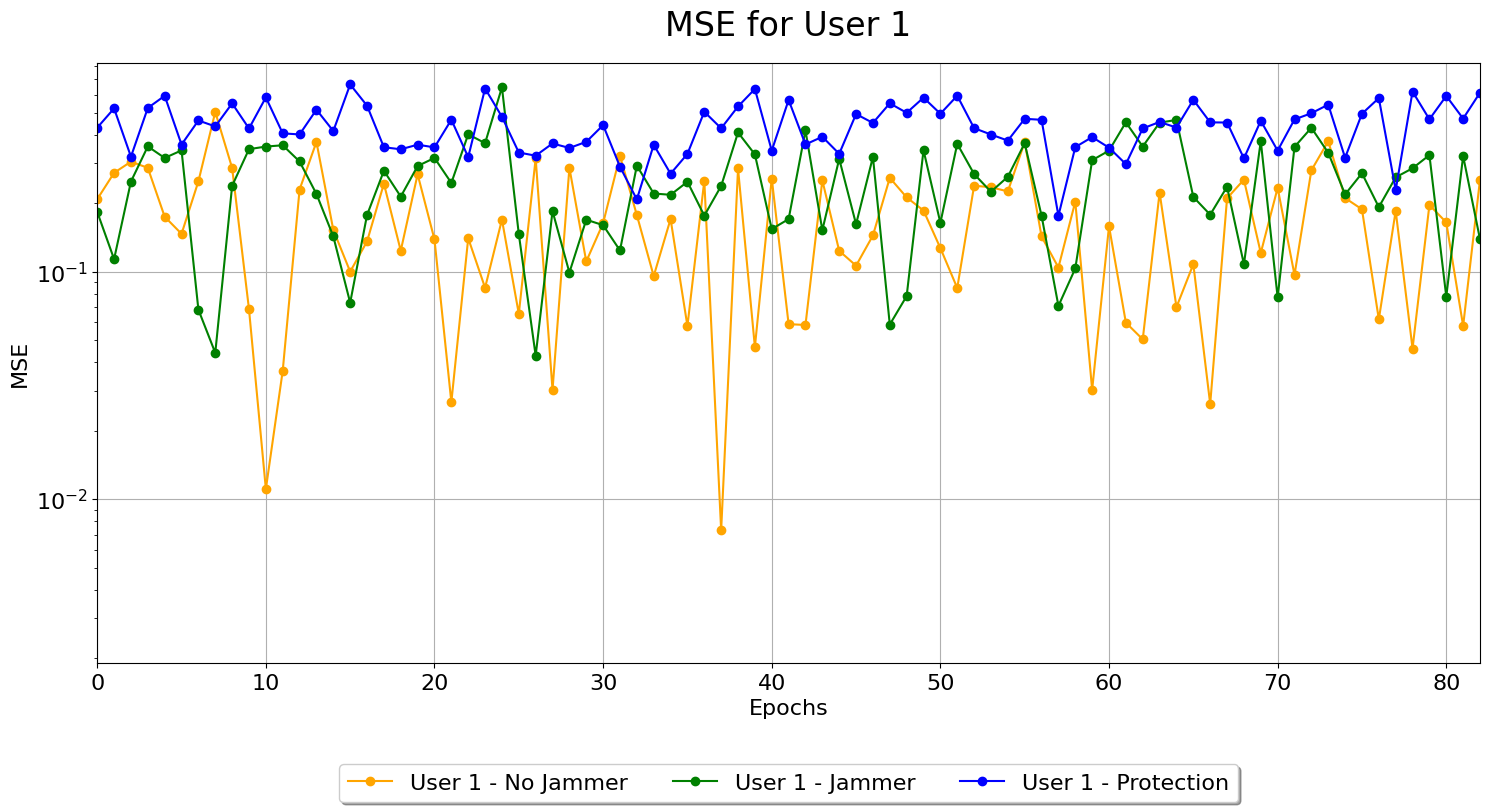

In [110]:
plot_user_scenarios_interactive(all_mses_w_protection, "User 1", speed=0.001)

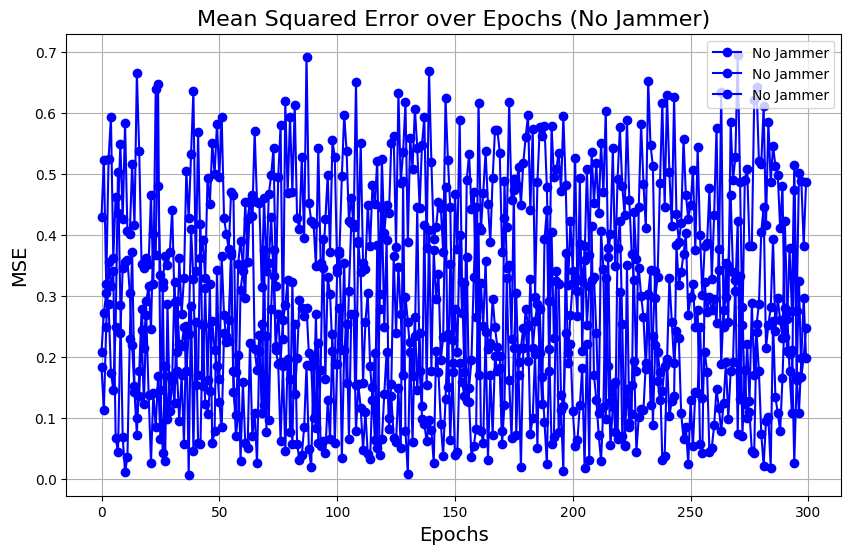

In [46]:
import matplotlib.pyplot as plt

# Load MSEs
mse_filepath = '/home/aladin/latest/resilient_sfl/mse_files/'
all_mses_no_jammer = np.load(mse_filepath + 'mse_no_jammer.npy', allow_pickle=True)
all_mses_no_jammer = all_mses_w_protection[:300]

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(all_mses_no_jammer, marker='o', linestyle='-', color='b', label='No Jammer')

plt.xlabel('Epochs', fontsize=14)
plt.ylabel('MSE', fontsize=14)
plt.title('Mean Squared Error over Epochs (No Jammer)', fontsize=16)
plt.legend()
plt.grid(True)

plt.show()